import asyncio
import json
import os
from dataclasses import dataclass
from datetime import timedelta

import flyte
import flyte.report
from flyte.ai.agents import Agent, AgentResult

flyte.init_from_config()

_image = (
    flyte.Image.from_debian_base(name="multi-agent", python_version=(3, 12))
    .with_pip_packages("litellm")
)

agent_env = flyte.TaskEnvironment(
    name="multi_agent_env",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
)

## Implementation with Flyte v2 + the Agent harness

This notebook implements **two collaboration models** with `Agent` instances:

1. **Sequential handoff** — researcher `Agent` → writer `Agent` (blog-post pipeline).
2. **Parallel specialist review** — draft → [fact-checker ‖ SEO optimizer] `Agent`s → synthesizer `Agent`.

Each role is an `Agent`; an outer `@env.task` orchestrates them, passing each agent's typed output to the next. Sequential handoffs are plain `await`; parallel ones use `asyncio.gather`. The typed dataclass handoffs (`ResearchOutput`, `ArticleOutput`, …) are preserved — the agents fill them by returning JSON we parse.

#### CrewAI vs Flyte v2 + Agent harness

| Aspect | CrewAI | Flyte v2 + `Agent` harness |
|--------|--------|----------------------------|
| **Agent definition** | `Agent(role=..., goal=..., backstory=...)` | `Agent(name=..., instructions=..., model=...)` |
| **Data passing** | Implicit string passing | Typed dataclasses parsed from each agent's reply |
| **Collaboration structure** | `Process.sequential` / `hierarchical` | Plain `await` (sequential) + `asyncio.gather` (parallel) |
| **Each agent** | Framework-managed | A nested, traced action in the Flyte UI |
| **Retry granularity** | Entire crew re-run | Per-task retries |
| **Secrets** | `.env` | `flyte.Secret` injected by cluster |

### 1. Install dependencies

In [ ]:
!uv pip install 'flyte[tui]' litellm

### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

### 2. Export your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...


### 3. Import dependencies and configure the Flyte TaskEnvironment

In [13]:
import asyncio
import json
import os
from dataclasses import dataclass
from datetime import timedelta

from anthropic import AsyncAnthropic
import flyte
import flyte.report

flyte.init_from_config()

_image = (
    flyte.Image.from_debian_base(name="multi-agent", python_version=(3, 12))
    .with_pip_packages("anthropic>=0.25.0")
)

agent_env = flyte.TaskEnvironment(
    name="multi_agent_env",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
)



### 4. Define data models

Each agent's output is a **typed dataclass** — not a raw string. This is the critical difference from string-passing frameworks:

- The downstream agent receives structured data it can reference by field name
- Flyte stores each agent's output in object storage, making the handoff durable and inspectable
- The Flyte UI shows the full typed output of each agent as a structured record
- If any agent fails and retries, it re-receives the same typed upstream output — exactly as before

In [14]:
# ── Sequential pipeline: Researcher → Writer ───────────────────────────────────

@dataclass
class ResearchOutput:
    topic: str = ""
    summary: str = ""
    key_findings: list[str] | None = None
    notable_examples: list[str] | None = None
    recommended_angle: str = ""
    sources_consulted: int = 0

    def __post_init__(self) -> None:
        if self.key_findings is None:
            self.key_findings = []
        if self.notable_examples is None:
            self.notable_examples = []


@dataclass
class ArticleOutput:
    topic: str = ""
    title: str = ""
    body: str = ""
    word_count: int = 0
    target_audience: str = ""
    key_points: list[str] | None = None

    def __post_init__(self) -> None:
        if self.key_points is None:
            self.key_points = []


# ── Parallel review: Fact-checker ‖ SEO optimizer → Synthesizer ───────────────

@dataclass
class FactCheckResult:
    issues_found: list[str] | None = None
    verified_claims: list[str] | None = None
    overall_accuracy_score: int = 0
    recommendation: str = ""

    def __post_init__(self) -> None:
        if self.issues_found is None:
            self.issues_found = []
        if self.verified_claims is None:
            self.verified_claims = []


@dataclass
class SEOResult:
    suggested_title: str = ""
    meta_description: str = ""
    primary_keywords: list[str] | None = None
    secondary_keywords: list[str] | None = None
    readability_score: int = 0
    suggested_improvements: list[str] | None = None

    def __post_init__(self) -> None:
        if self.primary_keywords is None:
            self.primary_keywords = []
        if self.secondary_keywords is None:
            self.secondary_keywords = []
        if self.suggested_improvements is None:
            self.suggested_improvements = []


@dataclass
class FinalArticle:
    topic: str = ""
    title: str = ""
    body: str = ""
    meta_description: str = ""
    primary_keywords: list[str] | None = None
    fact_check_score: int = 0
    readability_score: int = 0
    editorial_notes: list[str] | None = None

    def __post_init__(self) -> None:
        if self.primary_keywords is None:
            self.primary_keywords = []
        if self.editorial_notes is None:
            self.editorial_notes = []


## Part 1: Sequential Handoff Pattern

The most common multi-agent structure: Agent A completes its specialized task and passes its typed output to Agent B. The Flyte workflow makes the handoff explicit — you can see in the DAG view exactly what data flows from Researcher to Writer.

```
researcher_agent(topic) ──► ResearchOutput ──► writer_agent(topic, research) ──► ArticleOutput
```

### 5a. Researcher agent

The researcher's role is information synthesis, not writing. Its output is structured so the writer can use `research.key_findings` and `research.recommended_angle` directly — no parsing required.

In [ ]:
RESEARCHER_SYSTEM = """\
You are a Senior Research Analyst specializing in technology and business trends.
Your role is information synthesis, not writing. Produce structured research findings
that a content writer can directly use.

Be specific: include concrete examples, data points, and named entities.
Your recommended_angle should suggest a unique editorial perspective, not a generic one.
Return your analysis in this exact JSON format:
{
  "summary": "<2-3 sentence overview>",
  "key_findings": ["finding 1", "finding 2", ...],
  "notable_examples": ["example 1", "example 2", ...],
  "recommended_angle": "<specific editorial angle for maximum impact>",
  "sources_consulted": <integer>
}"""


# The researcher is now an Agent instance (litellm-backed) instead of a raw client call.
researcher_role = Agent(name="researcher", model="claude-sonnet-4-6", instructions=RESEARCHER_SYSTEM)


@flyte.trace
async def _research(topic: str) -> dict:
    """Traced research call via the researcher Agent (str -> dict, safe to trace)."""
    result = await researcher_role.run.aio(f"Research topic: {topic}")
    raw = (result.summary or "").strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    return json.loads(raw)


@agent_env.task(
    retries=3,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
)
async def researcher_agent(topic: str) -> ResearchOutput:
    """
    Researcher agent — Phase 1 of the sequential pipeline.

    Specialized role: information synthesis and editorial strategy.
    The typed ResearchOutput ensures the Writer agent receives structured
    data, not a blob of text to parse.
    """
    data = await _research(topic=topic)
    return ResearchOutput(
        topic=topic,
        summary=data["summary"],
        key_findings=data["key_findings"],
        notable_examples=data["notable_examples"],
        recommended_angle=data["recommended_angle"],
        sources_consulted=data["sources_consulted"],
    )

### 5b. Writer agent

The writer receives the researcher's structured output and uses each field to produce a targeted article. Note that the writer's prompt is constructed from typed fields (`research.key_findings`, `research.recommended_angle`) — not from parsing a string. This is the key advantage of typed handoffs.

In [ ]:
WRITER_SYSTEM = """\
You are a Technical Content Writer who creates engaging, accurate articles for
a technical but non-specialist audience.
Use the research provided to write a compelling piece that follows the recommended angle.
Return your output in this exact JSON format:
{
  "title": "<compelling headline>",
  "body": "<full article text, ~500 words>",
  "word_count": <integer>,
  "target_audience": "<description of intended reader>",
  "key_points": ["main point 1", "main point 2", ...]
}"""


writer_role = Agent(name="writer", model="claude-sonnet-4-6", instructions=WRITER_SYSTEM)


async def _write(topic: str, research: ResearchOutput) -> dict:
    """Writing call via the writer Agent. Receives the researcher's typed fields as a brief."""
    research_brief = (
        f"Topic: {topic}\n\n"
        f"Research Summary: {research.summary}\n\n"
        f"Key Findings:\n" + "\n".join(f"- {f}" for f in (research.key_findings or [])) + "\n\n"
        f"Notable Examples:\n" + "\n".join(f"- {e}" for e in (research.notable_examples or [])) + "\n\n"
        f"Recommended editorial angle: {research.recommended_angle}"
    )

    result = await writer_role.run.aio(research_brief)
    raw = (result.summary or "").strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    return json.loads(raw)


@agent_env.task(
    retries=3,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def writer_agent(topic: str, research: ResearchOutput) -> ArticleOutput:
    """
    Writer agent — Phase 2 of the sequential pipeline.

    Receives typed ResearchOutput (not a string), so it uses research fields directly.
    """
    data = await _write(topic=topic, research=research)
    body = data["body"]
    article = ArticleOutput(
        topic=topic,
        title=data["title"],
        body=body,
        word_count=data.get("word_count", len(body.split())),
        target_audience=data["target_audience"],
        key_points=data["key_points"],
    )

    def _esc(t: str) -> str:
        return t.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

    key_points_html = "".join(f"<li>{_esc(p)}</li>" for p in (article.key_points or []))

    await flyte.report.replace.aio(
        "<html><body style='font-family:sans-serif;max-width:900px;margin:auto;padding:1.5em'>"
        "<h1>Writer Agent — Draft Article</h1>"
        f"<h2>{_esc(article.title)}</h2>"
        f"<p><strong>Topic:</strong> {_esc(article.topic)}</p>"
        f"<p><strong>Target audience:</strong> {_esc(article.target_audience)}</p>"
        f"<p><strong>Word count:</strong> {article.word_count}</p>"
        "<h3>Key Points</h3>"
        f"<ul>{key_points_html}</ul>"
        "<h3>Article</h3>"
        f"<pre style='background:#f4f4f4;padding:1em;border-radius:4px;white-space:pre-wrap'>{_esc(body)}</pre>"
        "</body></html>"
    )
    await flyte.report.flush.aio()

    return article

### 5c. Sequential collaboration task

The orchestrating task calls `researcher_agent` then `writer_agent` sequentially via plain `await`. In the Flyte UI this renders as child actions nested under the parent task — you can inspect each agent's typed inputs and outputs.

In [17]:
@agent_env.task(
    retries=1,
    timeout=timedelta(minutes=30),
    cache=flyte.Cache(behavior="disable"),
)
async def sequential_collaboration(topic: str) -> ArticleOutput:
    """
    Sequential handoff: Researcher → Writer.

    In Flyte V2 there is no @workflow decorator; tasks compose via plain Python.
    Calling one task from inside another creates a child action in the Flyte UI.

    If the writer step fails, only this orchestrating task retries — but because
    researcher_agent has cache="disable" here it will re-run. For production,
    give researcher_agent cache="auto" so retries skip the research step.
    """
    research = await researcher_agent(topic=topic)
    return await writer_agent(topic=topic, research=research)


### 6. Run the sequential pipeline locally

In [19]:
run = flyte.run(
    sequential_collaboration,
    topic="The rise of agentic AI systems and their impact on software development workflows",
)
run.wait()
print(run.url)


Output()

http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rttzlt6pc2br55vsb9sb


The `Report` tab for the `writer_agent` task will show the synthetized article:


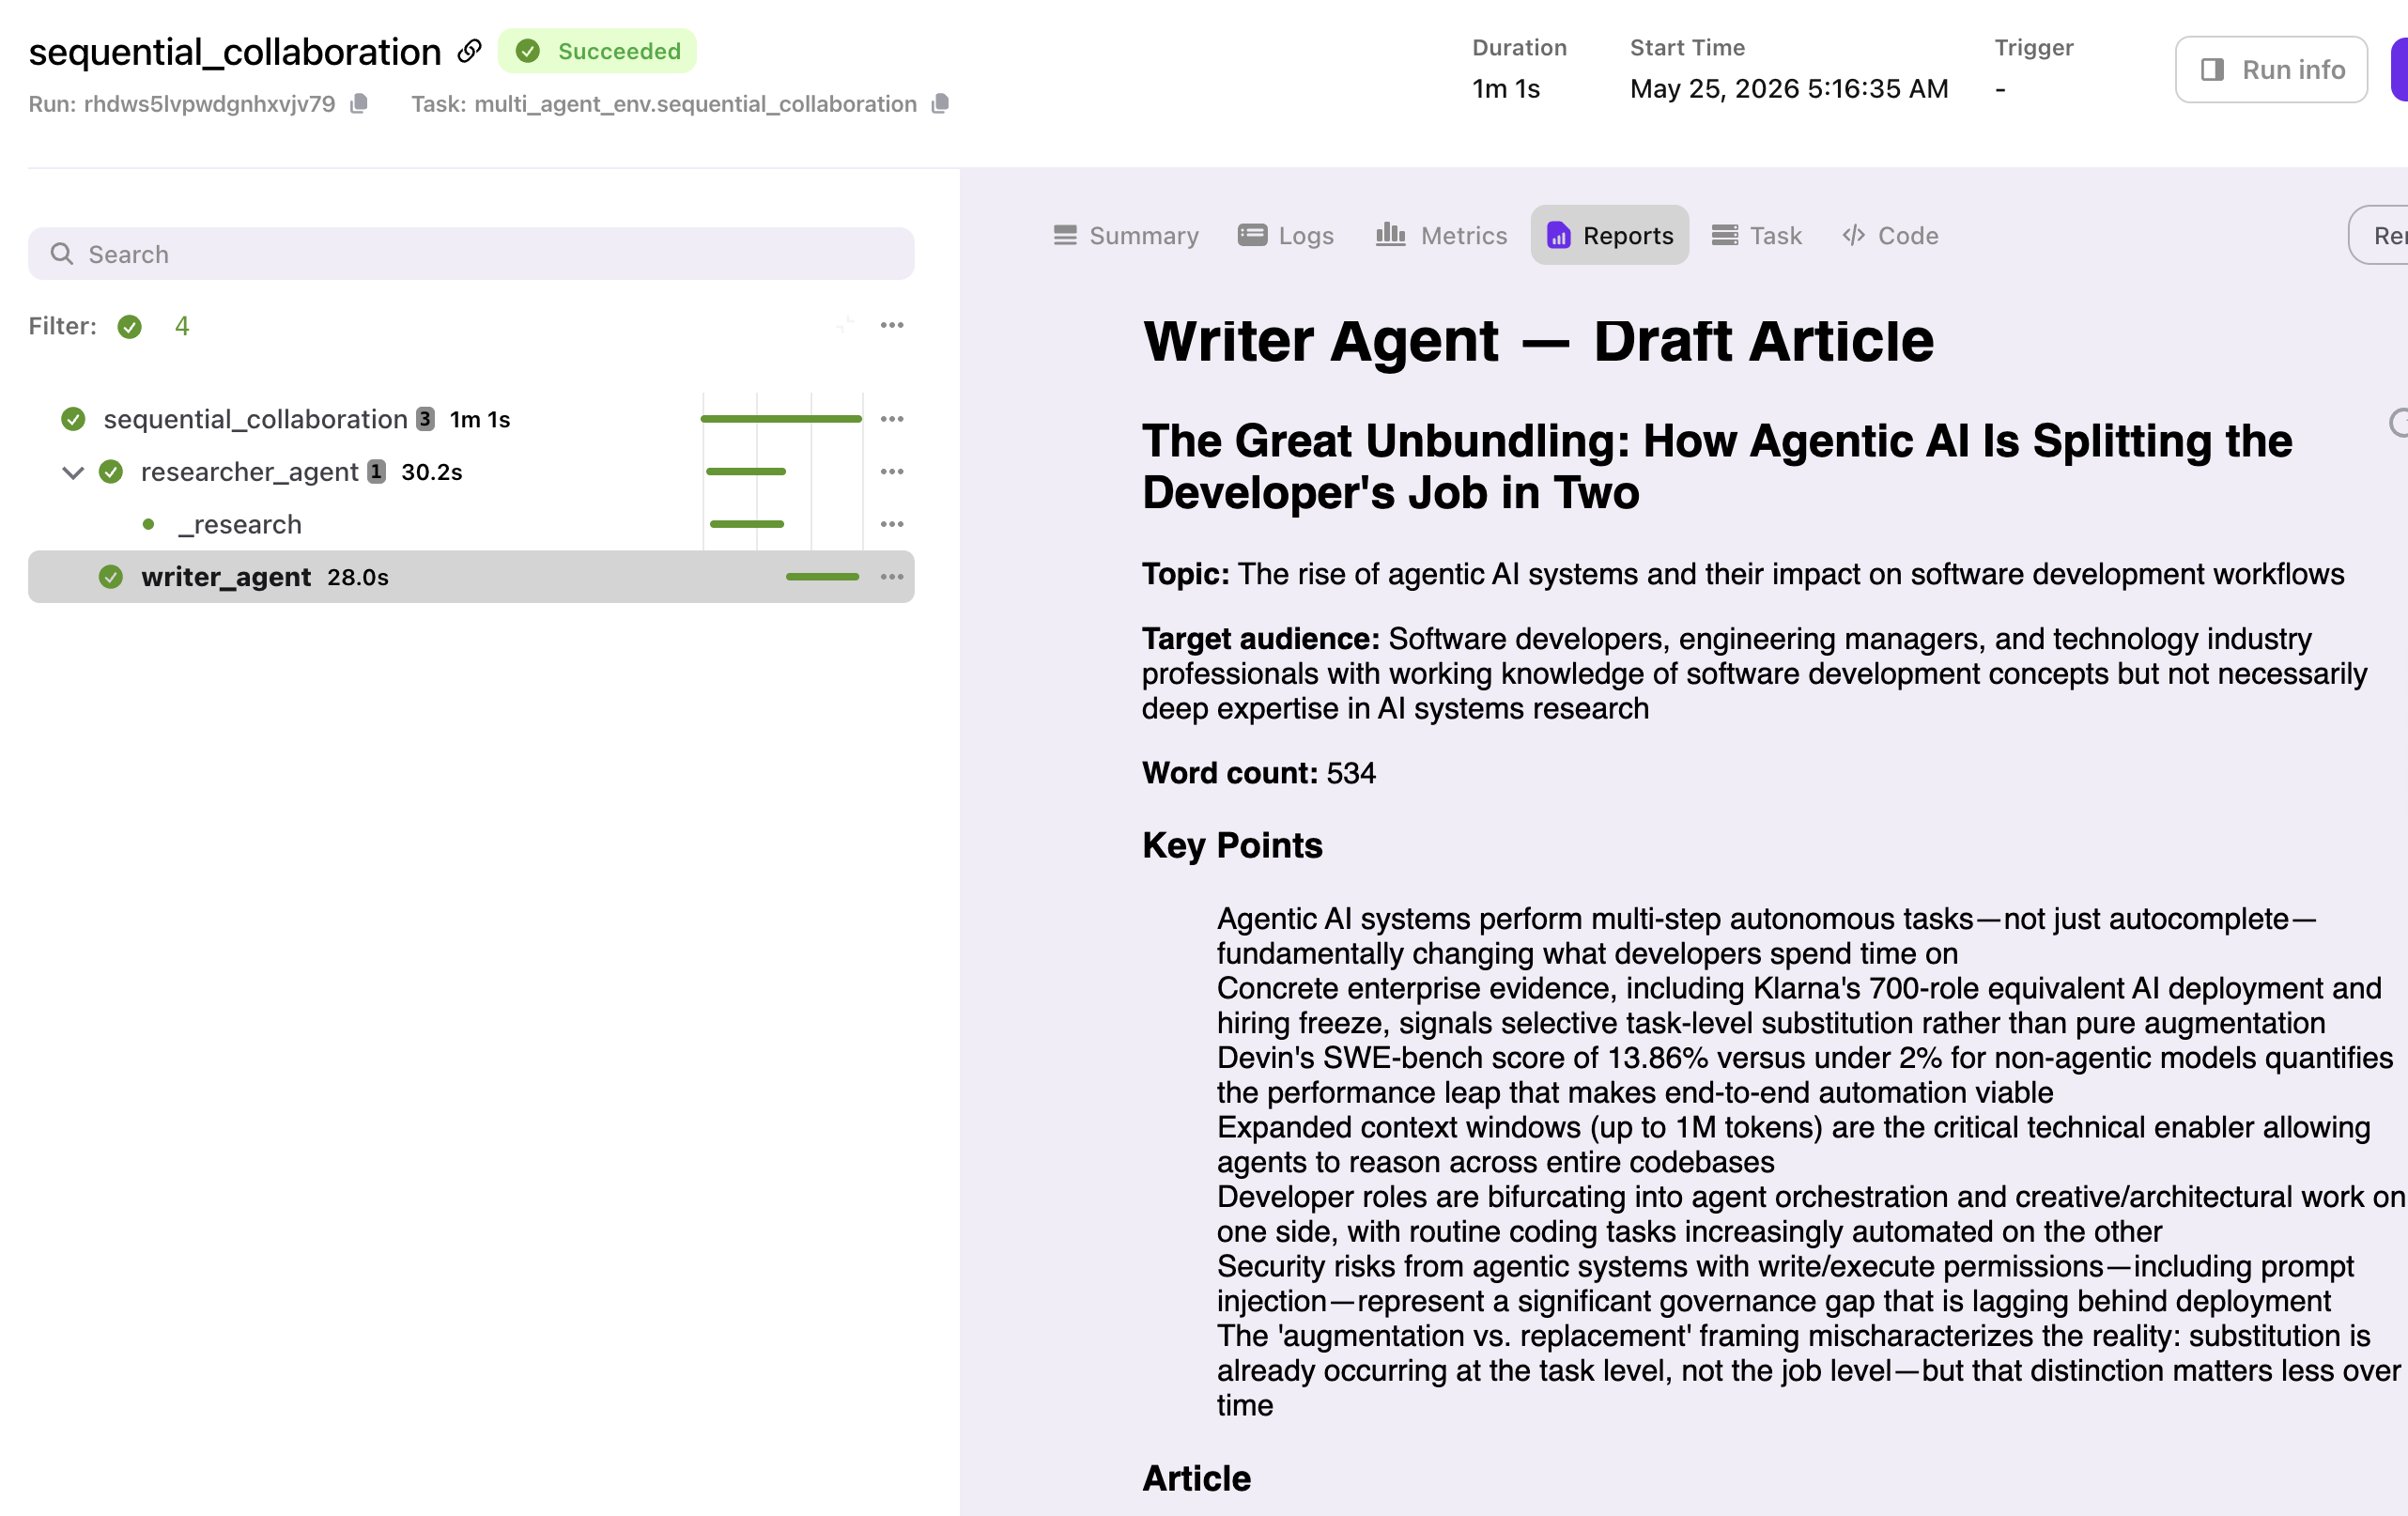

---

## Part 2: Parallel Specialist Review Pattern

Once a draft article exists, multiple specialists can review it **simultaneously** — fact-checker and SEO optimizer run in parallel, then a synthesizer merges their feedback into a final polished article.

```
                 ┌──► fact_checker_agent ──► FactCheckResult  ─┐
writer output ───┤                                              ├──► synthesizer_agent ──► FinalArticle
                 └──► seo_optimizer_agent ──► SEOResult ────────┘
```

In Flyte, this is expressed naturally in a workflow: two tasks with the same input and no dependency on each other execute in parallel. Flyte's scheduler dispatches them concurrently.

### 7a. Fact-checker and SEO optimizer agents

In [ ]:
FACT_CHECKER_SYSTEM = """\
You are a rigorous fact-checker. Your role is to evaluate an article for factual accuracy.
Focus on: unsupported claims, incorrect statistics, misleading statements, and outdated information.
Return your analysis in this exact JSON format:
{
  "issues_found": ["issue 1", ...],
  "verified_claims": ["accurate claim 1", ...],
  "overall_accuracy_score": <0-100>,
  "recommendation": "publish" | "revise" | "reject"
}"""

SEO_SYSTEM = """\
You are an SEO specialist. Analyze an article and provide optimization recommendations.
Focus on: keyword opportunities, title optimization, meta description, and readability.
Return your analysis in this exact JSON format:
{
  "suggested_title": "<SEO-optimized title>",
  "meta_description": "<150-160 char meta description>",
  "primary_keywords": ["keyword 1", ...],
  "secondary_keywords": ["keyword 1", ...],
  "readability_score": <0-100>,
  "suggested_improvements": ["improvement 1", ...]
}"""


# Two independent specialist Agents that run concurrently.
fact_checker_role = Agent(name="fact-checker", model="claude-sonnet-4-6", instructions=FACT_CHECKER_SYSTEM)
seo_role = Agent(name="seo-optimizer", model="claude-sonnet-4-6", instructions=SEO_SYSTEM)


async def _call_specialist(agent, content: str) -> dict:
    """Run a specialist Agent on the content and parse its JSON reply."""
    result = await agent.run.aio(content)
    raw = (result.summary or "").strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    return json.loads(raw)


@agent_env.task(
    retries=3,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
)
async def fact_checker_agent(article: ArticleOutput) -> FactCheckResult:
    """Fact-checker agent — runs in parallel with the SEO optimizer."""
    content = f"Title: {article.title}\n\nArticle:\n{article.body}"
    data = await _call_specialist(fact_checker_role, content)
    return FactCheckResult(
        issues_found=data.get("issues_found", []),
        verified_claims=data.get("verified_claims", []),
        overall_accuracy_score=data.get("overall_accuracy_score", 80),
        recommendation=data.get("recommendation", "revise"),
    )


@agent_env.task(
    retries=3,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
)
async def seo_optimizer_agent(article: ArticleOutput) -> SEOResult:
    """SEO optimizer agent — runs in parallel with the fact-checker."""
    content = f"Title: {article.title}\n\nArticle:\n{article.body}\n\nKey points: {', '.join(article.key_points or [])}"
    data = await _call_specialist(seo_role, content)
    return SEOResult(
        suggested_title=data.get("suggested_title", article.title),
        meta_description=data.get("meta_description", ""),
        primary_keywords=data.get("primary_keywords", []),
        secondary_keywords=data.get("secondary_keywords", []),
        readability_score=data.get("readability_score", 75),
        suggested_improvements=data.get("suggested_improvements", []),
    )

### 7b. Synthesizer agent

The synthesizer receives both specialist outputs and produces the final polished article. It only starts after **both** parallel agents complete — Flyte handles this dependency automatically when the workflow declares it.

In [ ]:
SYNTHESIZER_SYSTEM = """\
You are an editorial director making final publication decisions.
You receive an article draft along with specialist reviews from a fact-checker and an SEO optimizer.
Your job: apply the recommended improvements and produce the final, publication-ready article.
Apply factual corrections, SEO improvements, and use the optimized title and meta description.
Return only the final article body text — no JSON, no preamble."""


synthesizer_role = Agent(name="synthesizer", model="claude-sonnet-4-6", instructions=SYNTHESIZER_SYSTEM)


async def _synthesize(
    article: ArticleOutput,
    fact_check: FactCheckResult,
    seo: SEOResult,
) -> str:
    """Synthesis call via the synthesizer Agent."""
    editorial_brief = (
        f"Original article:\nTitle: {article.title}\n{article.body}\n\n"
        f"FACT-CHECK REPORT (score: {fact_check.overall_accuracy_score}/100, "
        f"recommendation: {fact_check.recommendation}):\n"
        + ("Issues to fix:\n" + "\n".join(f"- {i}" for i in (fact_check.issues_found or [])) if fact_check.issues_found else "No factual issues found.")
        + f"\n\nSEO REPORT (readability: {seo.readability_score}/100):\n"
        f"Optimized title: {seo.suggested_title}\n"
        f"Meta description: {seo.meta_description}\n"
        f"Primary keywords to incorporate: {', '.join(seo.primary_keywords or [])}\n"
        "Suggested improvements:\n"
        + "\n".join(f"- {s}" for s in (seo.suggested_improvements or []))
    )

    result = await synthesizer_role.run.aio(editorial_brief)
    return result.summary or ""


@agent_env.task(
    retries=3,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def synthesizer_agent(
    article: ArticleOutput,
    fact_check: FactCheckResult,
    seo: SEOResult,
) -> FinalArticle:
    """Synthesizer agent — runs after both parallel specialists complete."""
    final_body = await _synthesize(article=article, fact_check=fact_check, seo=seo)

    editorial_notes = []
    if fact_check.issues_found:
        editorial_notes.append(f"Fact-check: {len(fact_check.issues_found)} issues corrected")
    editorial_notes.extend((seo.suggested_improvements or [])[:3])

    def _esc(t: str) -> str:
        return t.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

    await flyte.report.replace.aio(
        "<html><body style='font-family:sans-serif;max-width:900px;margin:auto;padding:1.5em'>"
        "<h1>Multi-Agent Pipeline — Final Article Report</h1>"
        f"<h2>Fact-Check Score: {fact_check.overall_accuracy_score}/100 ({fact_check.recommendation})</h2>"
        + ("<ul>" + "".join(f"<li>{_esc(i)}</li>" for i in (fact_check.issues_found or [])) + "</ul>" if fact_check.issues_found else "<p>No factual issues.</p>")
        + f"<h2>SEO Score: {seo.readability_score}/100</h2>"
        f"<p>Optimized title: <strong>{_esc(seo.suggested_title)}</strong></p>"
        f"<p>Keywords: {_esc(', '.join(seo.primary_keywords or []))}</p>"
        "<h2>Final Article</h2>"
        f"<pre style='background:#f4f4f4;padding:1em;border-radius:4px;white-space:pre-wrap'>{_esc(final_body)}</pre>"
        "</body></html>"
    )
    await flyte.report.flush.aio()

    return FinalArticle(
        topic=article.topic,
        title=seo.suggested_title,
        body=final_body,
        meta_description=seo.meta_description,
        primary_keywords=seo.primary_keywords,
        fact_check_score=fact_check.overall_accuracy_score,
        readability_score=seo.readability_score,
        editorial_notes=editorial_notes,
    )

### 8. Full pipeline task

The complete pipeline combines both patterns in a single orchestrating task:
1. Sequential: `researcher_agent → writer_agent`
2. Parallel: `fact_checker_agent ‖ seo_optimizer_agent` via `asyncio.gather`
3. Sequential: `synthesizer_agent` (runs after both complete)

In Flyte V2, parallelism within a task is plain `asyncio.gather` — no special workflow primitives needed.

In [23]:
@agent_env.task(
    retries=1,
    timeout=timedelta(minutes=60),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def full_content_pipeline(topic: str) -> FinalArticle:
    """
    Complete multi-agent content pipeline.

    Execution order:
      1. researcher_agent(topic)          — sequential
      2. writer_agent(topic, research)    — sequential (depends on 1)
      3. fact_checker_agent ‖ seo_optimizer_agent  — parallel via asyncio.gather
      4. synthesizer_agent(...)           — sequential (depends on 3)

    In Flyte V2, parallelism inside a task is expressed with asyncio.gather.
    Both specialist agents run concurrently in the same async event loop;
    synthesizer starts only after both complete.
    """
    # Phase 1: Sequential research → writing
    research = await researcher_agent(topic=topic)
    article = await writer_agent(topic=topic, research=research)

    # Phase 2: Parallel specialist review
    fact_check, seo = await asyncio.gather(
        fact_checker_agent(article=article),
        seo_optimizer_agent(article=article),
    )

    # Phase 3: Synthesis (after both parallel tasks complete)
    return await synthesizer_agent(article=article, fact_check=fact_check, seo=seo)


### 9. Run the full pipeline on the devbox

In [24]:
run = flyte.run(
    full_content_pipeline,
    topic="How multi-agent AI systems are transforming enterprise software development",
)
run.wait()
print(run.url)


> Building 1 image...

> Building image multi-agent for environment multi_agent_env

✓ Built image for environment multi_agent_env: localhost:30000/multi-agent:b7e21ad4642010db89f88189de935c8b

Output()

http://localhost:30080/v2/domain/development/project/flytesnacks/runs/r6jtv9vhbflzck665bss


## Scaling the pattern

### Adding more parallel specialists

The parallel fork-join pattern scales linearly. Adding a legal compliance agent or a tone-of-voice agent requires only:
1. A new typed output dataclass
2. A new `@agent_env.task` function
3. Adding it to the workflow and synthesizer signature

Flyte schedules all parallel tasks concurrently — no thread management or `asyncio.gather` boilerplate needed at the workflow level.

In [ ]:
# Example: adding a legal compliance agent to the parallel review phase

@dataclass
class ComplianceResult:
    issues: list[str]
    risk_level: str   # "low" | "medium" | "high"


compliance_role = Agent(
    name="compliance",
    model="claude-sonnet-4-6",
    instructions=(
        'You are a legal compliance reviewer. Identify any claims that could be legally '
        'problematic. Return JSON: {"issues": [...], "risk_level": "low|medium|high"}'
    ),
)


@agent_env.task(retries=3, timeout=timedelta(minutes=10), cache=flyte.Cache(behavior="disable"))
async def compliance_agent(article: ArticleOutput) -> ComplianceResult:
    """Legal compliance reviewer — runs in parallel with fact-checker and SEO optimizer."""
    result = await compliance_role.run.aio(article.body)
    data = json.loads((result.summary or "").strip())
    return ComplianceResult(issues=data["issues"], risk_level=data["risk_level"])


# In the pipeline, add compliance_agent alongside the other parallel tasks:
# fact_check, seo, compliance = await asyncio.gather(
#     fact_checker_agent(article=article),
#     seo_optimizer_agent(article=article),
#     compliance_agent(article=article),
# )

### Supervisor pattern

For dynamic task delegation — where a coordinator decides *at runtime* which agents to call — implement a supervisor as a single Flyte task that dispatches to sub-tasks using `asyncio.gather`. The coordinator reads the task requirements and routes to appropriate specialists.

In [ ]:
@agent_env.task(
    retries=3,
    timeout=timedelta(minutes=20),
    cache=flyte.Cache(behavior="disable"),
)
async def supervisor_agent(topic: str, required_reviews: list[str]) -> dict:
    """
    Supervisor pattern: a coordinator that dynamically dispatches to specialists.

    Unlike the fixed parallel fan-out above (where all agents always run), the
    supervisor decides at runtime which specialist Agents to call.
    """
    # Phase 1: Research and write (sequential)
    research = await _research(topic=topic)
    research_output = ResearchOutput(
        topic=topic,
        summary=research["summary"],
        key_findings=research["key_findings"],
        notable_examples=research["notable_examples"],
        recommended_angle=research["recommended_angle"],
        sources_consulted=research["sources_consulted"],
    )
    article_data = await _write(topic=topic, research=research_output)
    article = ArticleOutput(
        topic=topic,
        title=article_data["title"],
        body=article_data["body"],
        word_count=article_data.get("word_count", len(article_data["body"].split())),
        target_audience=article_data["target_audience"],
        key_points=article_data["key_points"],
    )

    # Phase 2: Dynamically dispatch only the requested specialist Agents, in parallel
    review_coros = []
    if "fact_check" in required_reviews:
        review_coros.append(_call_specialist(fact_checker_role, article.body))
    if "seo" in required_reviews:
        review_coros.append(_call_specialist(seo_role, article.body))

    review_results = await asyncio.gather(*review_coros)

    return {
        "article": article.body,
        "reviews": dict(zip(required_reviews, review_results)),
    }